# Q1 - Analyse and Visualise the BESSTIE Dataset

This notebook presents an exploratory analysis of the **BESSTIE** dataset, focusing on label distributions, class imbalance, vocabulary overlap, cross-variety similarity, and selected linguistic patterns across **en-AU**, **en-IN**, and **en-UK**.

The analysis uses the **train**, **validation**, and **test** splits to examine how sentiment and sarcasm are distributed across varieties, and to compare lexical and grammatical patterns relevant to sequence classification.

## Section 1 - Install Dependencies

This section installs any required packages that are needed to run the notebook successfully. It ensures that the environment is ready for data loading, analysis, visualisation, and linguistic processing.

In [1]:
import sys
%pip -q install datasets matplotlib matplotlib-venn nltk numpy pandas seaborn scikit-learn spacy transformers
!{sys.executable} -m spacy download en_core_web_sm -q

Note: you may need to restart the kernel to use updated packages.
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')


## Section 2 - Import Requirements and Create Output Folder

This section imports the Python libraries used throughout the notebook and creates the output directory for saving generated plots and summary tables.

In [2]:
import os, re
import matplotlib.pyplot as plt
import nltk
import numpy as np
import pandas as pd
import seaborn as sns
import spacy

from collections import Counter
from datasets import load_dataset
from matplotlib_venn import venn3
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

nltk.download('punkt')
nltk.download('stopwords')

nlp = spacy.load("en_core_web_sm")
sns.set_context("talk")

# Paths
ROOT_DIR    = os.getcwd()
OUT_DIR     = f"{ROOT_DIR}/Results"
PLOTS_DIR   = os.path.join(OUT_DIR, "plots")
CSV_DIR   = os.path.join(OUT_DIR, "csv")

for d in [OUT_DIR, PLOTS_DIR, CSV_DIR]:
    os.makedirs(d, exist_ok=True)

[nltk_data] Downloading package punkt to
[nltk_data]     /user/HS401/zt00372/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /user/HS401/zt00372/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


## Section 3 - Load dataset from Hugging Face

This section loads the BESSTIE dataset from Hugging Face. The train, validation, and test splits are accessed separately so that their structure and distributions can be analysed throughout the notebook.

In [3]:
dataset = load_dataset("surrey-nlp/BESSTIE-CW-26")
print(dataset)

DatasetDict({
    train: Dataset({
        features: ['text', 'variety', 'source', 'Sentiment', 'Sarcasm'],
        num_rows: 3747
    })
    validation: Dataset({
        features: ['text', 'variety', 'source', 'Sentiment', 'Sarcasm'],
        num_rows: 313
    })
    test: Dataset({
        features: ['text', 'variety', 'source', 'Sentiment', 'Sarcasm'],
        num_rows: 2183
    })
})


## Section 4 - Convert Splits to Data Frames

This section converts the dataset splits into pandas DataFrames, making them easier to manipulate for descriptive statistics, visualisation, and lexical analysis.

In [4]:
train = dataset['train'].to_pandas()
validation = dataset['validation'].to_pandas()
test = dataset['test'].to_pandas()

# Add split labels
train['split'] = 'Train'
validation['split'] = 'Validation'
test['split'] = 'Test'

# Add word_length
for data_frame in [train, validation, test]:
    data_frame['word_length'] = data_frame['text'].astype(str).apply(lambda x: len(x.split()))

# Combined dataframe for overview analysis
data_frames = pd.concat([train, validation, test], ignore_index=True)

print("Full dataset shape:", data_frames.shape)
print("\nVariety counts:\n", data_frames['variety'].value_counts())
print("\nSource counts:\n", data_frames['source'].value_counts())

Full dataset shape: (6243, 7)

Variety counts:
 variety
en-IN    2332
en-UK    2004
en-AU    1907
Name: count, dtype: int64

Source counts:
 source
Google    3142
Reddit    3101
Name: count, dtype: int64


## Section 5 - Explore Structure

This section performs an initial inspection of the dataset structure, including its available fields and example entries. The aim is to confirm the schema and verify that the expected labels and metadata are present before further analysis.

In [5]:
for split_name in dataset.keys():
    print(f"[{split_name.title()}]")
    print(f"Rows: {len(dataset[split_name])}")
    print(f"Columns: {dataset[split_name].column_names}")
    print(f"{dataset[split_name].to_pandas().head(5)}\n")

[Train]
Rows: 3747
Columns: ['text', 'variety', 'source', 'Sentiment', 'Sarcasm']
                                                text variety  source  \
0  I'm a member of the Green Party but I'll be vo...   en-UK  Reddit   
1  Yeah it blew out to 3x what it was budgeted fo...   en-AU  Reddit   
2  Food was pretty great. A little dry, but I am ...   en-AU  Google   
3  Firstly the staff seemed as if they did n't wa...   en-UK  Google   
4  We came for lunch and enjoyed the food we orde...   en-UK  Google   

   Sentiment  Sarcasm  
0        0.0      0.0  
1        0.0      1.0  
2        1.0      0.0  
3        0.0      0.0  
4        1.0      0.0  

[Validation]
Rows: 313
Columns: ['text', 'variety', 'source', 'Sentiment', 'Sarcasm']
                                                text variety  source  \
0  Had a great meal here. Friendly service, great...   en-AU  Google   
1  Meh. Such a shame. Such a waste. Only single u...   en-AU  Google   
2  How many sensors are broken? It is 

## Section 6 - Dataset Summary Table

This section provides a compact summary of the dataset across the train, validation, and test splits. The table reports split size, variety counts, source counts, and label counts.

In [6]:
summary_rows = []

for split_name, data_frame in [('Train', train), ('Validation', validation), ('Test', test)]:
    summary_rows.append({
        "split": split_name,
        "rows": len(data_frame),
        "en-AU": int((data_frame["variety"] == "en-AU").sum()),
        "en-IN": int((data_frame["variety"] == "en-IN").sum()),
        "en-UK": int((data_frame["variety"] == "en-UK").sum()),
        "Google": int((data_frame["source"] == "Google").sum()),
        "Reddit": int((data_frame["source"] == "Reddit").sum()),
        "Positive": int((data_frame["Sentiment"] == 1).sum()),
        "Negative": int((data_frame["Sentiment"] == 0).sum()),
        "Sarcastic": int((data_frame["Sarcasm"] == 1).sum()),
        "Not Sarcastic": int((data_frame["Sarcasm"] == 0).sum()),
    })

summary_data_frames = pd.DataFrame(summary_rows)
display(summary_data_frames)
summary_data_frames.to_csv(f"{CSV_DIR}/dataset_summary_table.csv", index=False)

,split,rows,en-AU,en-IN,en-UK,Google,Reddit,Positive,Negative,Sarcastic,Not Sarcastic
0,Train,3747,1145,1399,1203,1874,1873,1840,1907,524,3223
1,Validation,313,95,117,101,167,146,153,160,44,269
2,Test,2183,667,816,700,1101,1082,1066,1117,305,1878


## Section 7 - Text Length Distribution

This section analyses text length across the corpus. Word-length distributions are useful because they reveal whether some varieties or domains contain systematically longer or shorter texts.

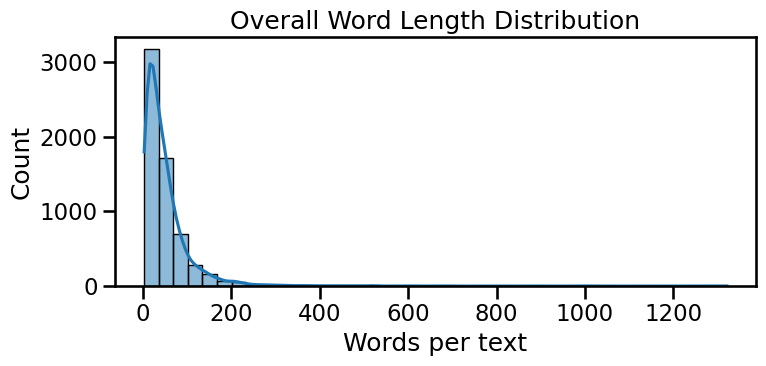

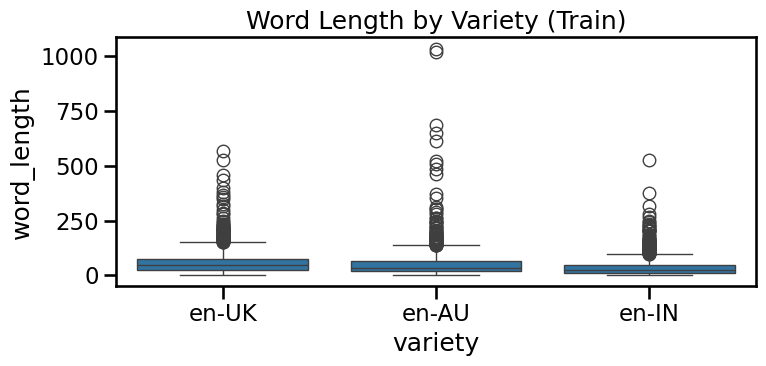

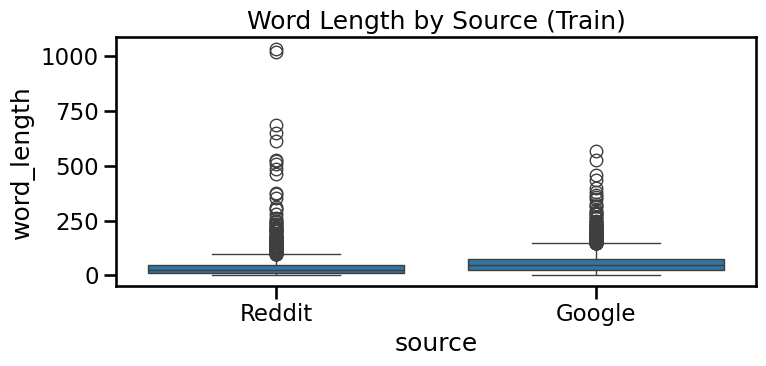

In [7]:
plt.figure(figsize=(8, 4))
sns.histplot(data=data_frames, x="word_length", bins=40, kde=True)
plt.title("Overall Word Length Distribution")
plt.xlabel("Words per text")
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/word_length_overall.png", dpi=150, bbox_inches="tight")
plt.show()

plt.figure(figsize=(8, 4))
sns.boxplot(data=train, x="variety", y="word_length")
plt.title("Word Length by Variety (Train)")
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/word_length_by_variety.png", dpi=150, bbox_inches="tight")
plt.show()

plt.figure(figsize=(8, 4))
sns.boxplot(data=train, x="source", y="word_length")
plt.title("Word Length by Source (Train)")
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/word_length_by_source.png", dpi=150, bbox_inches="tight")
plt.show()

## Section 8 - Split-Wise Label Distribution

This section compares label distributions across the train, validation, and test splits. Checking split consistency is important for understanding whether the evaluation setting reflects the training distribution and whether any imbalance is carried across splits.

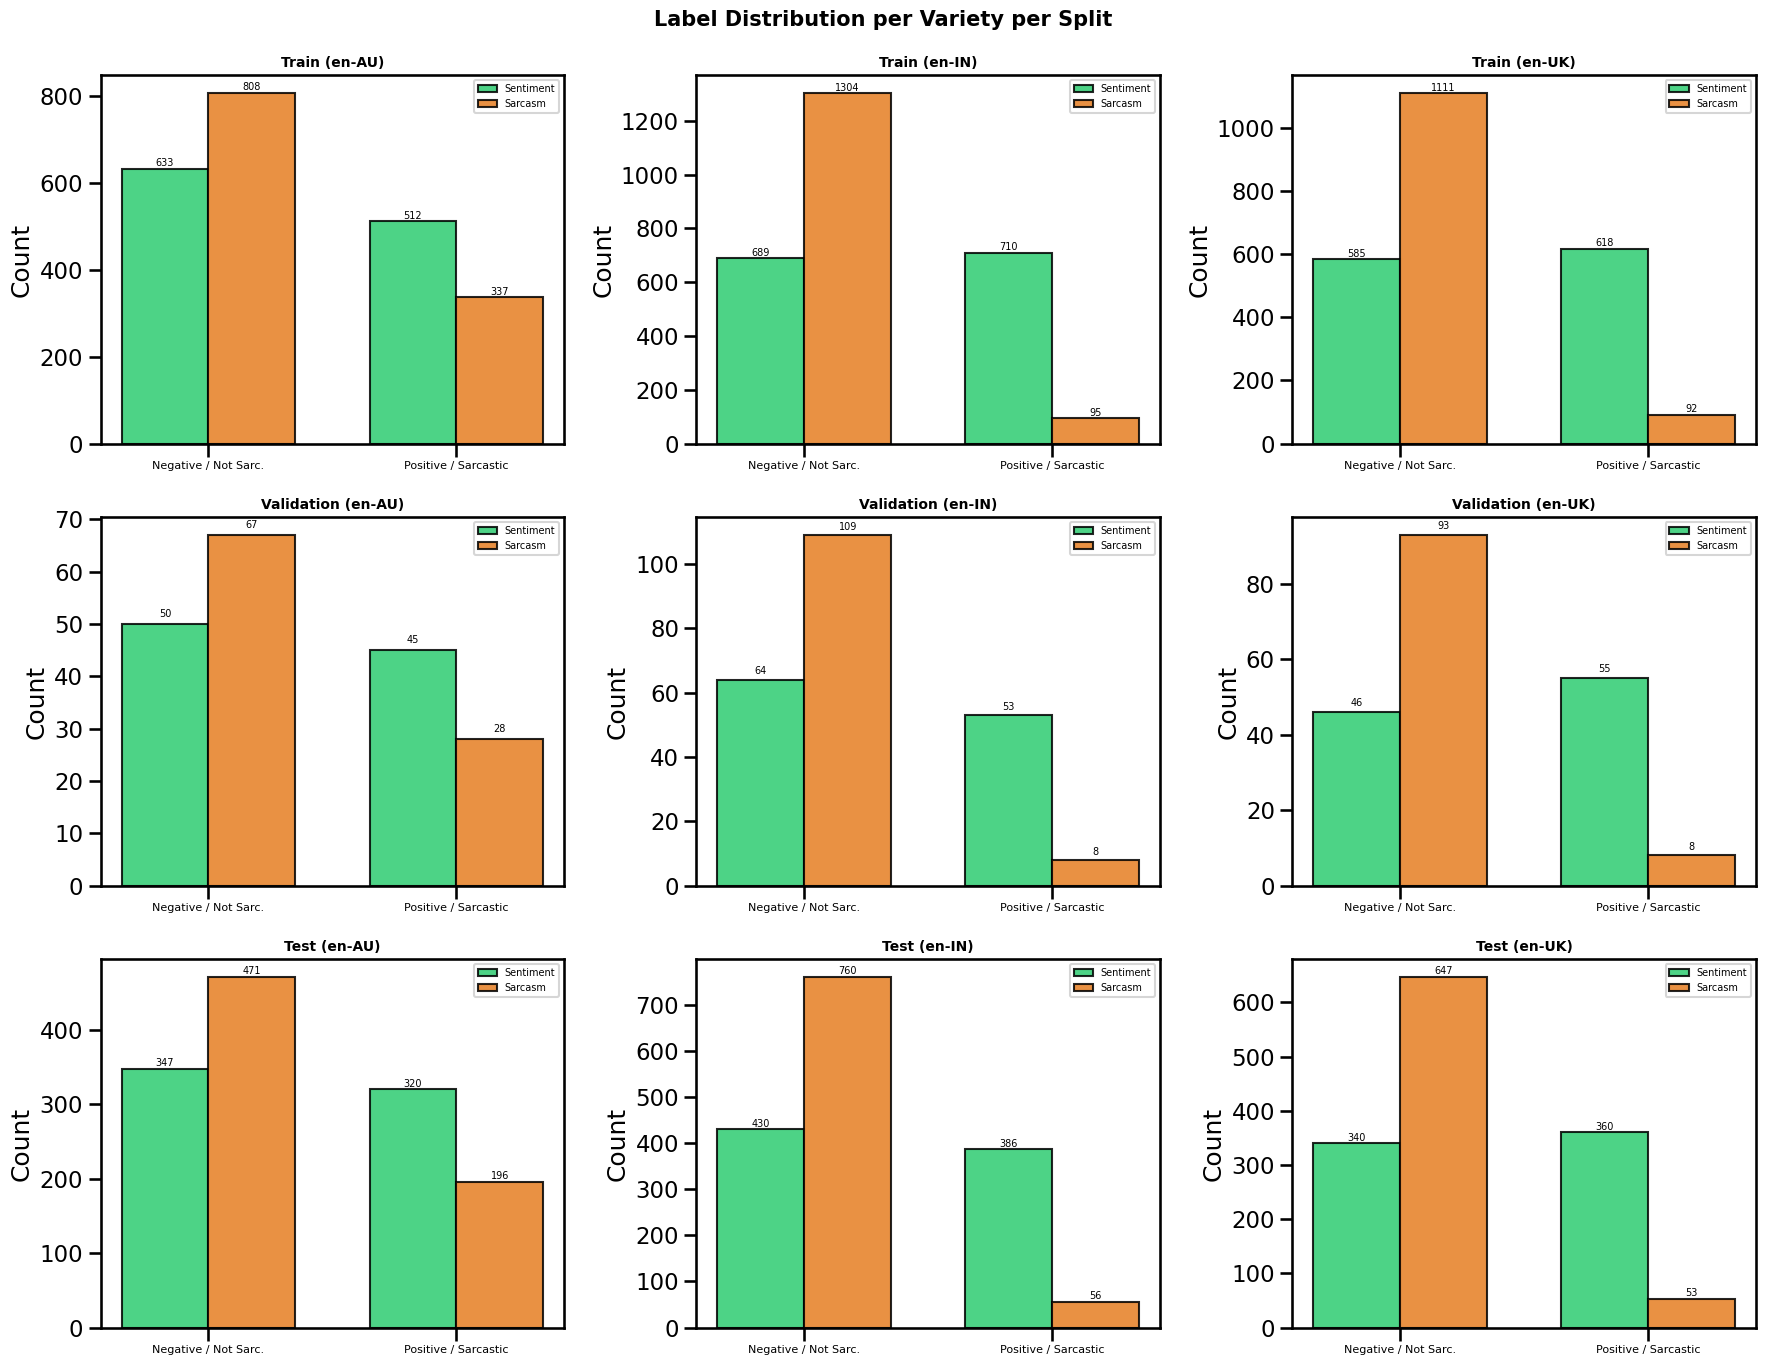

In [8]:
varieties = ['en-AU', 'en-IN', 'en-UK']
splits = ['Train', 'Validation', 'Test']
tasks = ['Sentiment', 'Sarcasm']

figure, axes = plt.subplots(3, 3, figsize=(18, 14))
figure.suptitle('Label Distribution per Variety per Split', fontsize=15, fontweight='bold')

for row, split in enumerate(splits):
    for col, variety in enumerate(varieties):
        ax = axes[row][col]
        subset = data_frames[
            (data_frames['variety'] == variety) &
            (data_frames['split'] == split)
        ]

        sarcasm_counts = subset['Sarcasm'].value_counts().sort_index()
        sentiment_counts = subset['Sentiment'].value_counts().sort_index()

        x = np.arange(2)
        width = 0.35
        sarc_labels = ['Not Sarcastic', 'Sarcastic']
        sent_labels = ['Negative', 'Positive']

        sarc_vals = [sarcasm_counts.get(0.0, 0), sarcasm_counts.get(1.0, 0)]
        sent_vals = [sentiment_counts.get(0.0, 0), sentiment_counts.get(1.0, 0)]

        ax.bar(x - width/2, sent_vals, width, label='Sentiment',
               color='#2ecc71', alpha=0.85, edgecolor='black')
        ax.bar(x + width/2, sarc_vals, width, label='Sarcasm',
               color='#e67e22', alpha=0.85, edgecolor='black')

        ax.set_xticks(x)
        ax.set_xticklabels(['Negative / Not Sarc.', 'Positive / Sarcastic'], fontsize=8)
        ax.set_title(f'{split} ({variety})', fontsize=10, fontweight='bold')
        ax.set_ylabel('Count')
        ax.legend(fontsize=7)

        # Add count labels
        for bar in ax.patches:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                    str(int(bar.get_height())), ha='center', va='bottom', fontsize=7)

plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/split_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 9 - Sentiment and Sarcasm Distribution Across Varieties

This section compares the distributions of **Sentiment** and **Sarcasm** across the three English varieties (**en-AU**, **en-IN**, and **en-UK**). The purpose is to identify whether some varieties are more strongly associated with particular labels, which may later influence modelling behaviour and transferability.

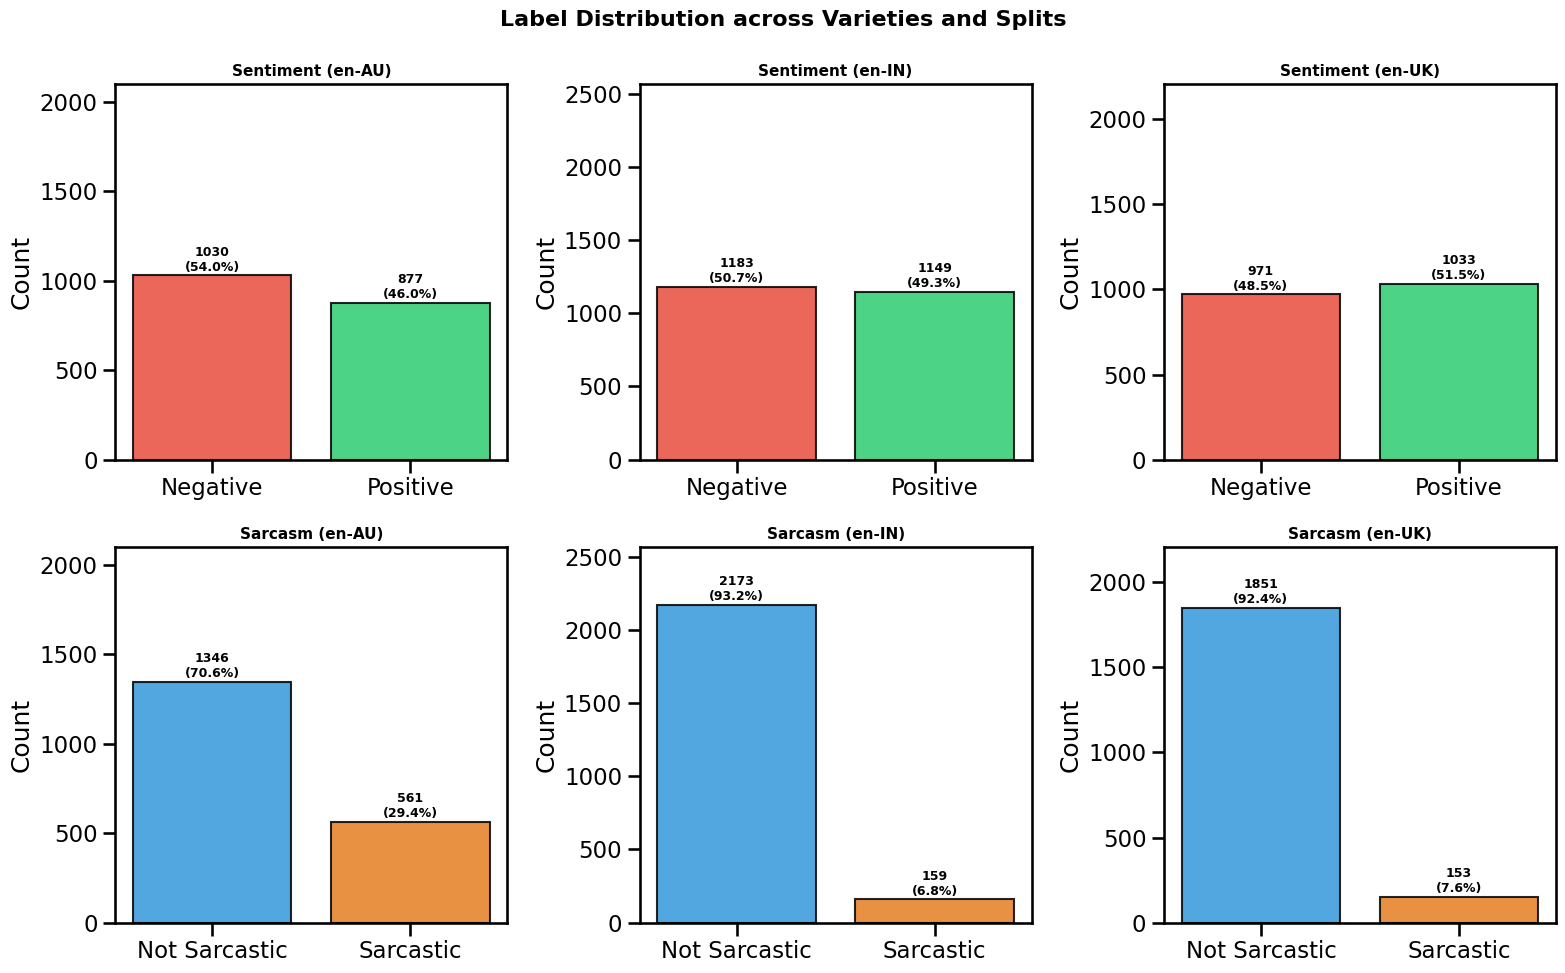

In [9]:
figure, axes = plt.subplots(2, 3, figsize=(16, 10))
figure.suptitle('Label Distribution across Varieties and Splits', fontsize=16, fontweight='bold')

label_names = {
    'Sentiment': {0: 'Negative', 1: 'Positive'},
    'Sarcasm': {0: 'Not Sarcastic', 1: 'Sarcastic'}
}
colors = {'Sentiment': ['#e74c3c', '#2ecc71'], 'Sarcasm': ['#3498db', '#e67e22']}

for row, task in enumerate(tasks):
    for col, variety in enumerate(varieties):
        ax = axes[row][col]
        subset = data_frames[data_frames['variety'] == variety]
        counts = subset[task].value_counts().sort_index()
        labels = [label_names[task][i] for i in counts.index]
        bars = ax.bar(labels, counts.values, color=colors[task], edgecolor='black', alpha=0.85)

        # Add percentage labels on bars
        total = counts.sum()
        for bar, count in zip(bars, counts.values):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                    f'{count}\n({count/total*100:.1f}%)',
                    ha='center', va='bottom', fontsize=9, fontweight='bold')

        ax.set_title(f'{task} ({variety})', fontsize=11, fontweight='bold')
        ax.set_ylabel('Count')
        ax.set_ylim(0, total * 1.1)

plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/label_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 10 - Domain Analysis (Google vs Reddit)

This section studies how the two source domains, **Google** and **Reddit**, differ in their label distributions. Domain analysis is important because user behaviour, writing style, and communicative intent may vary across platforms, affecting both sentiment and sarcasm.

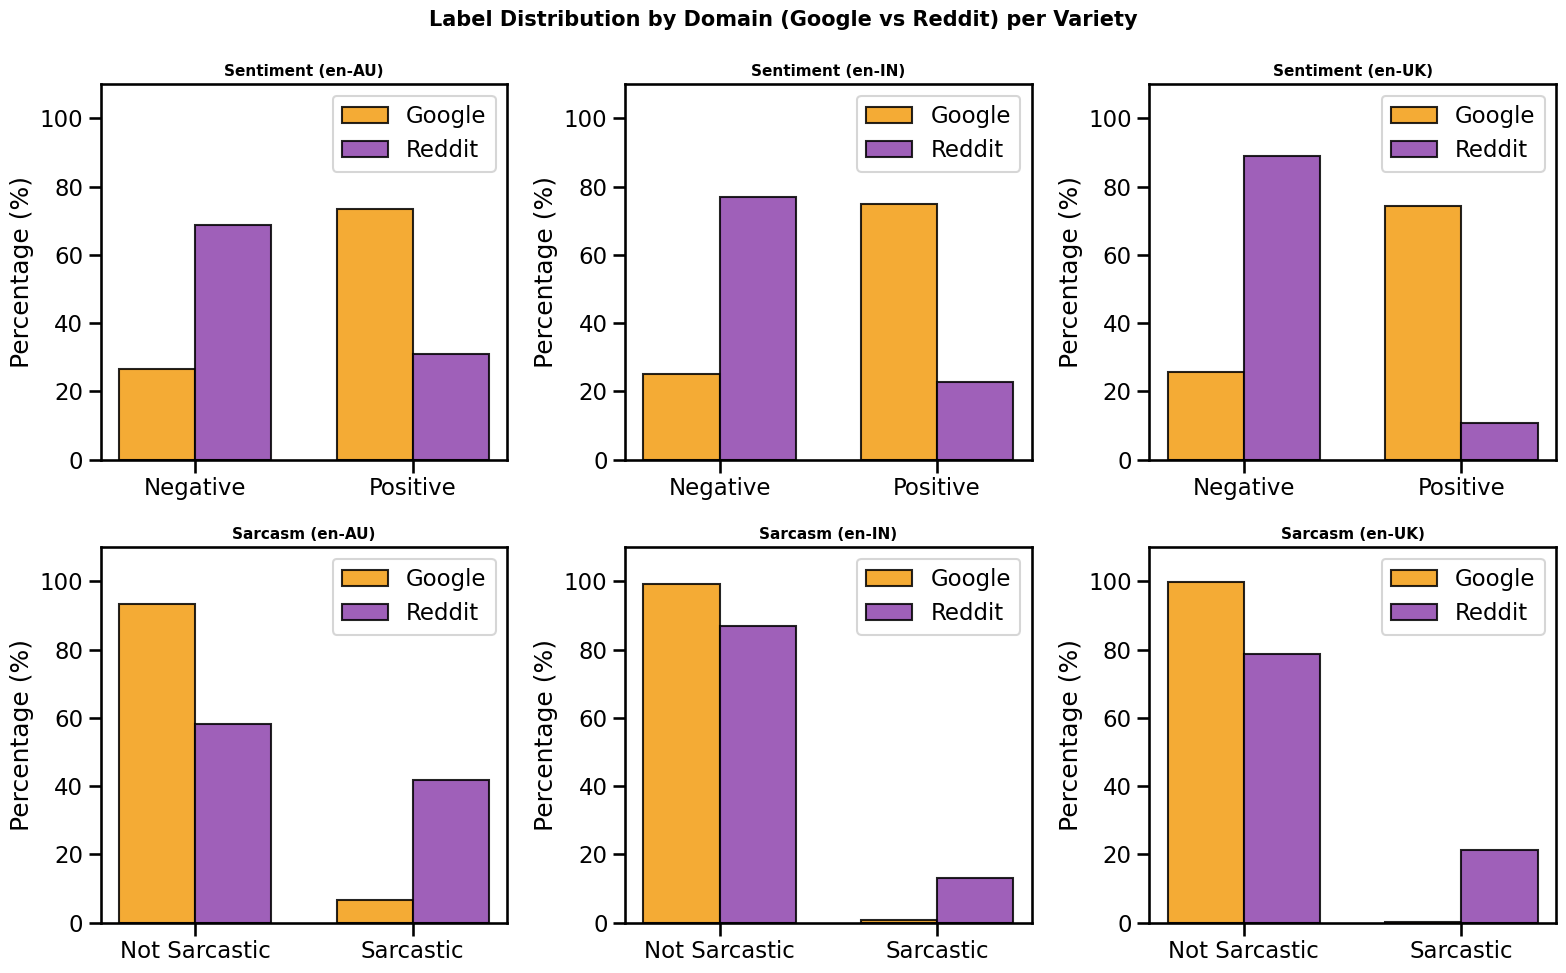

In [10]:
figure, axes = plt.subplots(2, 3, figsize=(16, 10))
figure.suptitle('Label Distribution by Domain (Google vs Reddit) per Variety', fontsize=15, fontweight='bold')

for row, task in enumerate(tasks):
    for col, variety in enumerate(varieties):
        ax = axes[row][col]
        subset = data_frames[data_frames['variety'] == variety]

        google = subset[subset['source'] == 'Google'][task].value_counts(normalize=True).reindex([0,1], fill_value=0) * 100
        reddit = subset[subset['source'] == 'Reddit'][task].value_counts(normalize=True).reindex([0,1], fill_value=0) * 100

        x = np.arange(2)
        width = 0.35
        labels = [label_names[task][i] for i in sorted(subset[task].dropna().unique())]

        ax.bar(x - width/2, google.values, width, label='Google', color='#f39c12', alpha=0.85, edgecolor='black')
        ax.bar(x + width/2, reddit.values, width, label='Reddit', color='#8e44ad', alpha=0.85, edgecolor='black')

        ax.set_xticks(x)
        ax.set_xticklabels(labels)
        ax.set_title(f'{task} ({variety})', fontsize=11, fontweight='bold')
        ax.set_ylabel('Percentage (%)')
        ax.legend()
        ax.set_ylim(0, 110)

plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/domain_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 11 - Sarcasm Imbalance by Domain and Variety

This section examines sarcasm imbalance more closely by combining both **source** and **variety**. The aim is to identify where sarcastic examples are concentrated and to highlight potential sources of bias that may affect downstream experiments.

Variety Source  Sarcasm %  Positive Sentiment %  Count
  en-AU Google        5.7                  73.3    389
  en-AU Reddit       41.7                  30.0    756
  en-IN Google        1.0                  76.8    716
  en-IN Reddit       12.9                  23.4    683
  en-UK Google        0.1                  74.3    769
  en-UK Reddit       21.0                  10.8    434



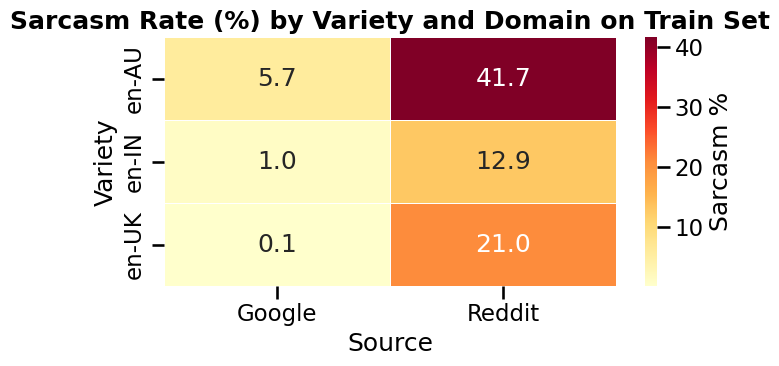

In [11]:
rows = []
for variety in varieties:
    for source in ['Google', 'Reddit']:
        subset = train[(train['variety'] == variety) & (train['source'] == source)]
        if len(subset) == 0:
            continue
        sarcasm_percentage = subset['Sarcasm'].mean() * 100
        sentiment_percentage = subset['Sentiment'].mean() * 100
        rows.append({'Variety': variety, 'Source': source,
                     'Sarcasm %': round(sarcasm_percentage, 1),
                     'Positive Sentiment %': round(sentiment_percentage, 1),
                     'Count': len(subset)})

summary_data_frames = pd.DataFrame(rows)
print(f"{summary_data_frames.to_string(index=False)}\n")

# Heatmap
pivot = summary_data_frames.pivot(index='Variety', columns='Source', values='Sarcasm %')
plt.figure(figsize=(7, 4))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='YlOrRd', linewidths=0.5, cbar_kws={'label': 'Sarcasm %'})
plt.title('Sarcasm Rate (%) by Variety and Domain on Train Set', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/sarcasm_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 12 - Frequent Words Across Varieties

This section examines the most frequent words used in each variety. Frequent-word analysis provides an intuitive view of lexical differences and helps identify shared or variety-specific vocabulary patterns.

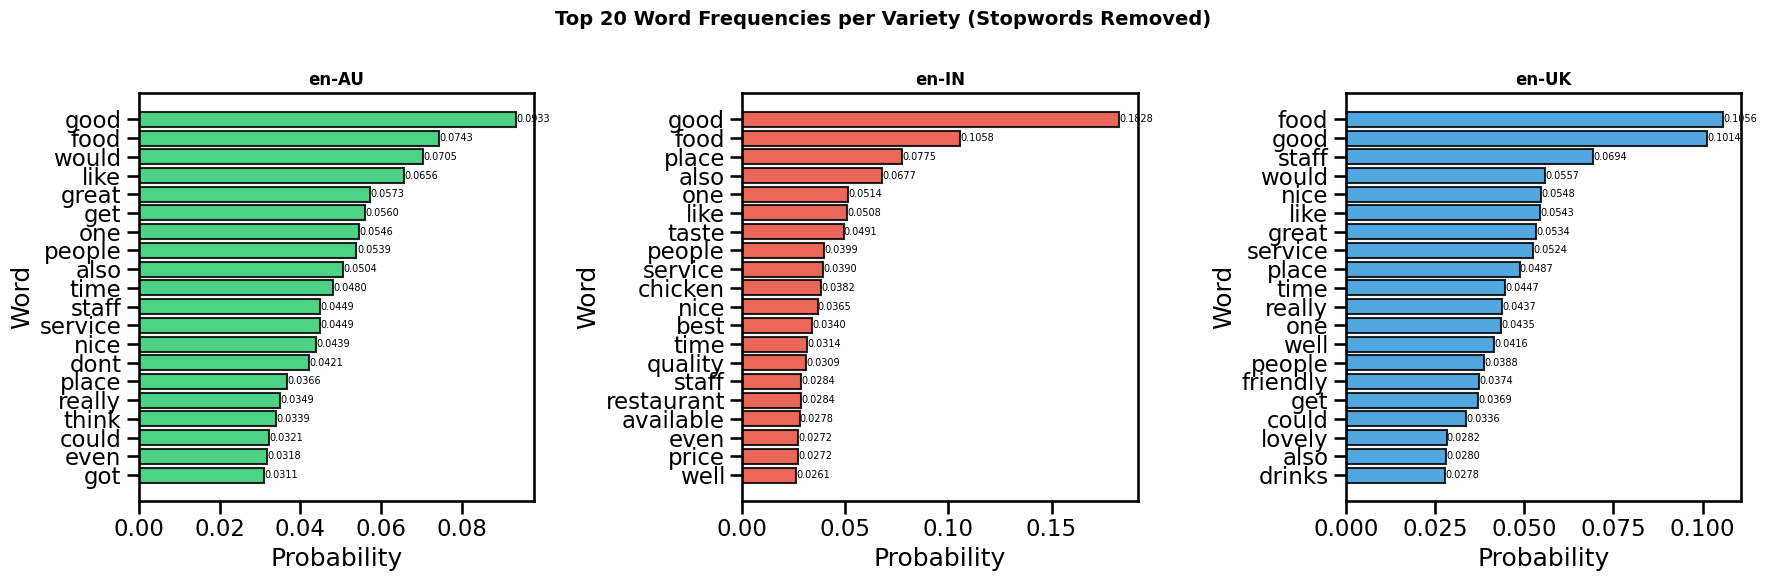

In [12]:
def get_word_freq(df, variety, top_n=20, remove_stopwords=True):
    stop_words = set(stopwords.words('english')) if remove_stopwords else set()

    texts = df[df['variety'] == variety]['text'].dropna().tolist()
    words = []
    for text in texts:
        # Clean text - lowercase, remove punctuation
        cleaned = re.sub(r'[^a-zA-Z\s]', '', text.lower())
        tokens = [w for w in cleaned.split()
                  if w not in stop_words and len(w) > 2]
        words.extend(tokens)

    freq = Counter(words)
    top_words = freq.most_common(top_n)

    if not top_words:
        return [], []

    return zip(*top_words)  # returns (words, counts)

figure, axes = plt.subplots(1, 3, figsize=(18, 6))
figure.suptitle('Top 20 Word Frequencies per Variety (Stopwords Removed)',
             fontsize=14, fontweight='bold')

bar_colors = {'en-AU': '#2ecc71', 'en-IN': '#e74c3c', 'en-UK': '#3498db'}

for ax, variety in zip(axes, varieties):
    words, counts = get_word_freq(train, variety, top_n=20)
    words, counts = list(words), list(counts)

    total = sum(counts)
    probs = [c/total for c in counts]

    bars = ax.barh(words[::-1], probs[::-1],
                   color=bar_colors[variety], alpha=0.85, edgecolor='black')
    ax.set_title(f'{variety}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Probability')
    ax.set_ylabel('Word')

    # Add value labels
    for bar, prob in zip(bars, probs[::-1]):
        ax.text(bar.get_width() + 0.0001, bar.get_y() + bar.get_height()/2,
                f'{prob:.4f}', va='center', fontsize=7)

plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/word_freq_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 13 - Lexical Markers of Sarcasm

This section explores lexical markers associated with sarcasm by comparing the word distributions of sarcastic and non-sarcastic texts. The goal is to identify words or expressions that appear more strongly linked to sarcastic usage in the dataset.

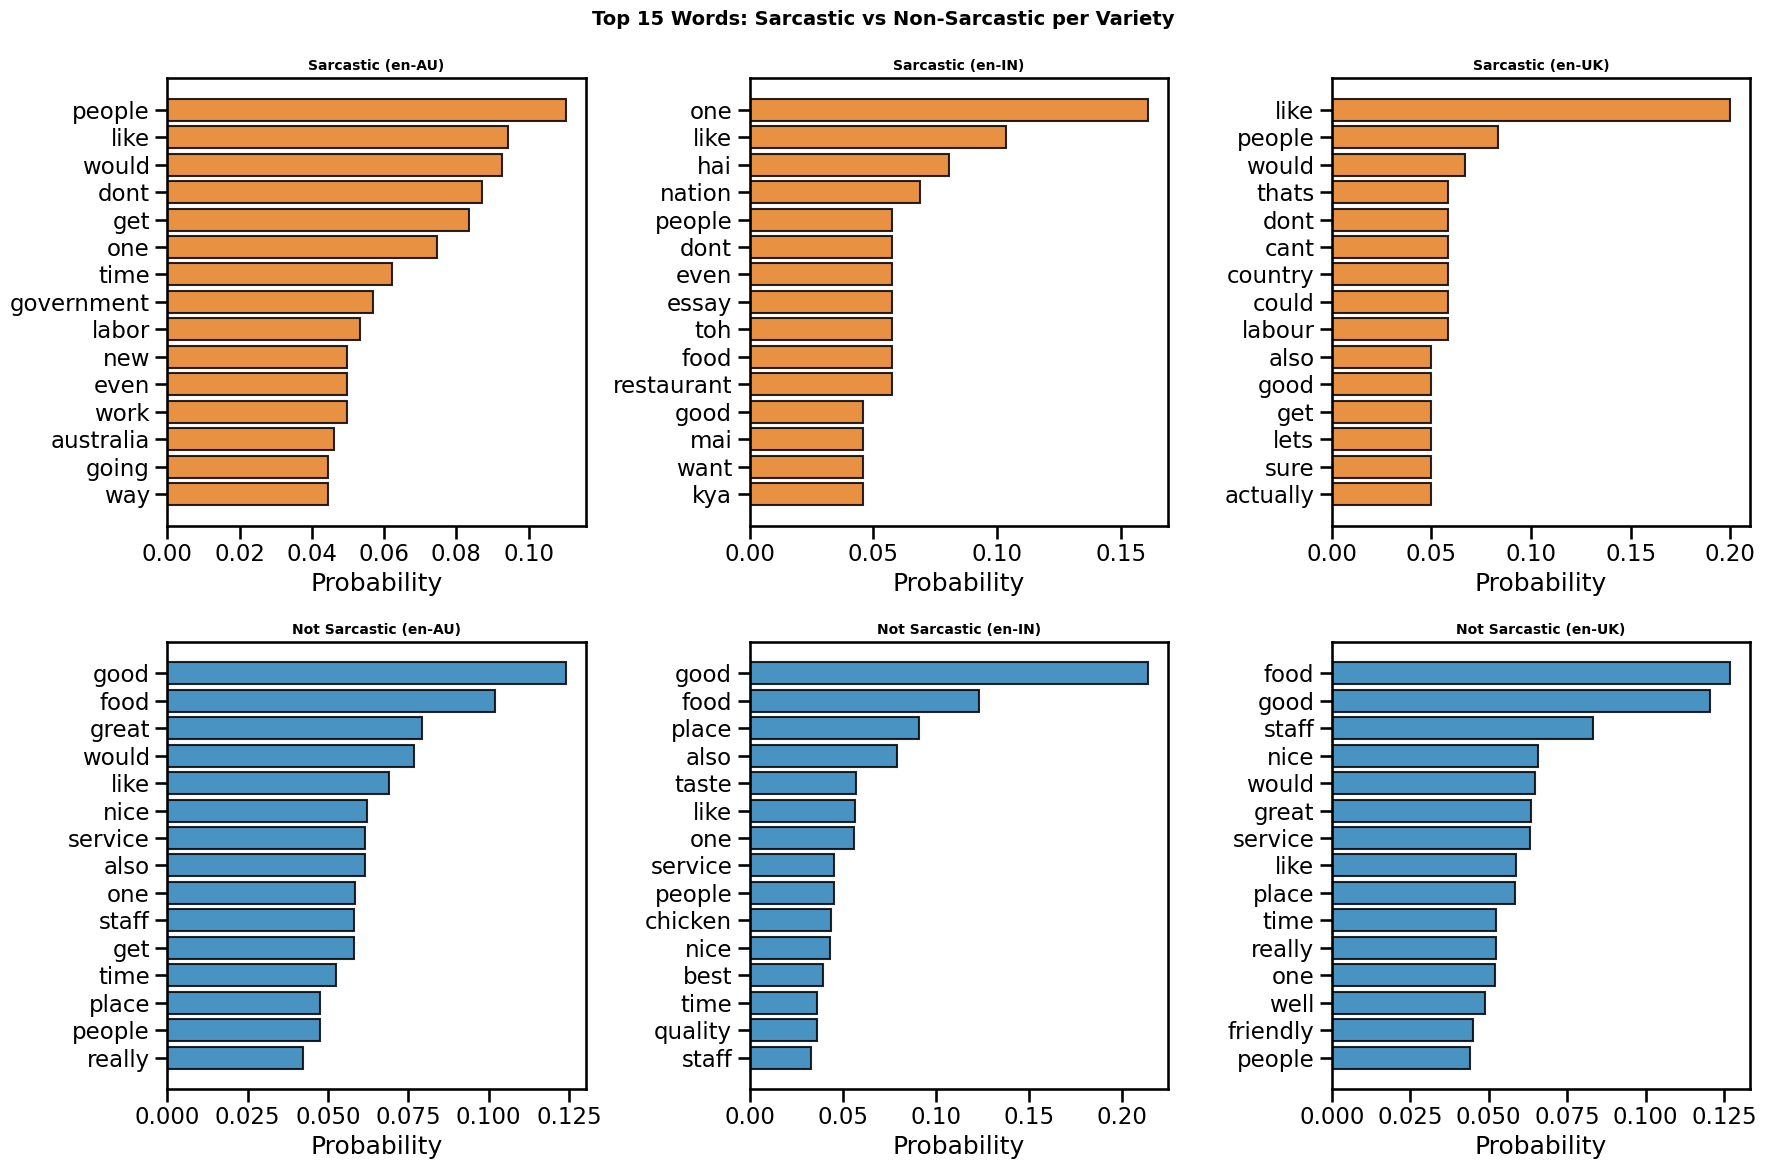

In [13]:
figure, axes = plt.subplots(2, 3, figsize=(18, 12))
figure.suptitle('Top 15 Words: Sarcastic vs Non-Sarcastic per Variety',
             fontsize=14, fontweight='bold')

sarcasm_colors = {1.0: '#e67e22', 0.0: '#2980b9'}
sarcasm_labels = {1.0: 'Sarcastic', 0.0: 'Not Sarcastic'}

for col, variety in enumerate(varieties):
    for row, label in enumerate([1.0, 0.0]):
        ax = axes[row][col]
        subset = train[(train['variety'] == variety) &
                          (train['Sarcasm'] == label)]

        if len(subset) < 5:
            ax.text(0.5, 0.5, 'Insufficient data',
                    ha='center', va='center', transform=ax.transAxes)
            continue

        words, counts = get_word_freq(subset, variety, top_n=15)
        words, counts = list(words), list(counts)
        total = sum(counts)
        probs = [c/total for c in counts]

        ax.barh(words[::-1], probs[::-1],
                color=sarcasm_colors[label], alpha=0.85, edgecolor='black')
        ax.set_title(f'{sarcasm_labels[label]} ({variety})',
                     fontsize=10, fontweight='bold')
        ax.set_xlabel('Probability')

plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/sarcasm_word_freq.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 14 - Vocabulary Overlap Using Jaccard Similarity

This section measures lexical overlap across English varieties using **Jaccard similarity**. Jaccard similarity provides a set-based measure of how much vocabulary is shared between varieties relative to their total combined vocabulary.

[Jaccard Similarity]
en-AU vs en-IN: 0.2177
en-UK vs en-IN: 0.2244
en-AU vs en-UK: 0.2576

        en-AU   en-IN   en-UK
en-AU  1.0000  0.2177  0.2576
en-IN  0.2177  1.0000  0.2244
en-UK  0.2576  0.2244  1.0000



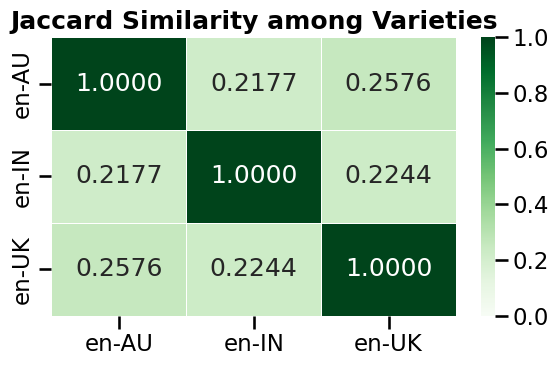


[Vocabulary Sizes]
en-AU unique tokens: 11661
en-UK unique tokens: 10926
en-IN unique tokens: 9968

[Tokens unique to each variety (sample)]
Only en-AU (6099 tokens): ['slam', 'meaning.', 'water,and', 'competing', 'projects,', 'determined."', 'distributed,', 'bamboo.', 'profession', 'nightmare.', 'poaching', 'helmet', 'sayings.', "a'racist'", 'existing', 'coma', 'steak(', 'fourth', 'waffles', 'norman.']
Only en-IN (5203 tokens): ['"soon-to-be-dad', 'moderate.', 'prachi', 'zoya', 'extent.', '"..other', 'embodying', 'lovee', 'showoff,', 'ulti', 'parlour(', 'yrs', 'wazwan.....', 'sweats', 'channel?', 'raghav.', 'switching', 'hukumat.....', 'har', 'elitist']
Only en-UK (5401 tokens): ['cardboard.', 'photograph', 'huge!!(', 'diane', 'brutality', 'legal/illegal', 'liar', 'faultless', 'anti-semitic)', '"loose', 'grimsby', 'cob.', 'clown.', 'flippent', 'meeting,', 'dictating', 'buttie,', 'nickle', 'london.', "....i'm"]


In [14]:
def get_vocabulary(df, variety):
    texts = df[df['variety'] == variety]['text'].dropna().tolist()
    tokens = set()
    for text in texts:
        tokens.update(text.lower().split())
    return tokens

# Use training set only
vocabulary_au = get_vocabulary(train, 'en-AU')
vocabulary_uk = get_vocabulary(train, 'en-UK')
vocabulary_in = get_vocabulary(train, 'en-IN')

def jaccard(set1, set2):
    intersection = len(set1 & set2)
    union = len(set1 | set2)
    return round(intersection / union, 4)

print("[Jaccard Similarity]")
print(f"en-AU vs en-IN: {jaccard(vocabulary_au, vocabulary_in)}")
print(f"en-UK vs en-IN: {jaccard(vocabulary_uk, vocabulary_in)}")
print(f"en-AU vs en-UK: {jaccard(vocabulary_au, vocabulary_uk)}\n")

jaccard_matrix = pd.DataFrame(index=varieties, columns=varieties, dtype=float)
vocab_map = {'en-AU': vocabulary_au, 'en-UK': vocabulary_uk, 'en-IN': vocabulary_in}

for v1 in varieties:
    for v2 in varieties:
        intersection = len(vocab_map[v1] & vocab_map[v2])
        union = len(vocab_map[v1] | vocab_map[v2])
        jaccard_matrix.loc[v1, v2] = round(intersection / union, 4)

print(f"{jaccard_matrix.round(4)}\n")

plt.figure(figsize=(6, 4))
sns.heatmap(jaccard_matrix.astype(float), annot=True, fmt='.4f', cmap='Greens', linewidths=0.5, vmin=0, vmax=1)
plt.title('Jaccard Similarity among Varieties', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/jaccard_similarity.png', dpi=150, bbox_inches='tight')
plt.show()
print();

# Unique tokens per variety
print("[Vocabulary Sizes]")
print(f"en-AU unique tokens: {len(vocabulary_au)}")
print(f"en-UK unique tokens: {len(vocabulary_uk)}")
print(f"en-IN unique tokens: {len(vocabulary_in)}\n")

print("[Tokens unique to each variety (sample)]")
only_au = vocabulary_au - vocabulary_uk - vocabulary_in
only_in = vocabulary_in - vocabulary_uk - vocabulary_au
only_uk = vocabulary_uk - vocabulary_au - vocabulary_in
print(f"Only en-AU ({len(only_au)} tokens): {list(only_au)[:20]}")
print(f"Only en-IN ({len(only_in)} tokens): {list(only_in)[:20]}")
print(f"Only en-UK ({len(only_uk)} tokens): {list(only_uk)[:20]}")

## Section 14.1 - Code-Mixed Term Inspection in en-IN

This section inspects sarcastic texts from the **en-IN** variety to identify potential
**code-mixed** vocabulary, where Hindi or other non-English terms appear alongside
English. Code-mixing is a well-documented feature of Indian English, particularly in
informal or social media contexts. Identifying such terms is relevant because
standard English pre-trained models may not have seen these tokens during training,
potentially contributing to the variety gap observed in downstream tasks.

In [15]:
print("=== Sample Sarcastic en-IN texts (checking for Hindi-English code-mixing) ===\n")
sarcastic_in = train[(train['variety'] == 'en-IN') & 
                      (train['Sarcasm'] == 1.0)]['text'].head(20).tolist()
for i, t in enumerate(sarcastic_in, 1):
    print(f"{i}. {t}")
    print("---")

# Also show unique en-IN tokens that look non-English (short proxy for code-mixing)
print("\n=== Potentially non-English tokens unique to en-IN (sample) ===")
non_english_proxy = [t for t in only_in 
                     if t.isalpha() and len(t) > 2 and t.islower()]
print(non_english_proxy[:40])

=== Sample Sarcastic en-IN texts (checking for Hindi-English code-mixing) ===

1. Imagine if this fellow led the independence movement
---
2. Yes please and destroy our economy more.
---
3. This is the political equivalent of and mand ka tola....
I cant believe people take this dimwit seriously
---
4. Arjun, you should've thought of all this when you were cheating on your gf with her SIL. 
What happened in your family should've taught you about the cons of being a homewrecker but I don't completely blame you. You were groomed by a much older woman who should've been more mature at that point. 
Didn't have the guts to leave her husband cause even she was dependent on Savlon's paycheck.
---
5. Its kangna vs pm.
Celebrity match of death
---
6. >Wait, wasn't reservation based on caste and weren't we told that Hinduism was bad and other religions were better because they didnt have casteism? I wonder why they'd need reservations.
#this
---
7. Dick tator and chaddi fans cannot read english. 

## Section 15 - Variety Similarity Using TF-IDF Cosine Similarity

This section complements the Jaccard analysis by computing **cosine similarity** over TF-IDF representations. While Jaccard focuses on shared vocabulary items, cosine similarity captures similarity in the overall distribution of word usage across varieties.

[TF-IDF Cosine Similarity]
        en-AU   en-IN   en-UK
en-AU  1.0000  0.7357  0.8649
en-IN  0.7357  1.0000  0.7954
en-UK  0.8649  0.7954  1.0000



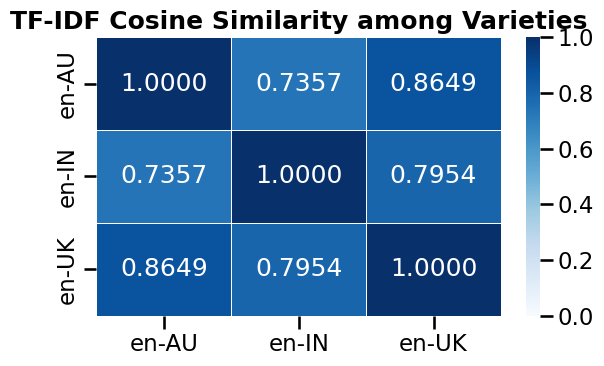

In [16]:
texts_by_variety = { v: " ".join(train[train['variety'] == v]['text'].dropna().tolist()) for v in varieties }

tfidf = TfidfVectorizer(max_features=10000, stop_words='english')
tfidf_matrix = tfidf.fit_transform(list(texts_by_variety.values()))

cosine = cosine_similarity(tfidf_matrix)
cosine_data_frames = pd.DataFrame(cosine, index=varieties, columns=varieties)

print("[TF-IDF Cosine Similarity]")
print(f"{cosine_data_frames.round(4)}\n")

plt.figure(figsize=(6, 4))
sns.heatmap(cosine_data_frames, annot=True, fmt='.4f', cmap='Blues', linewidths=0.5, vmin=0, vmax=1)
plt.title('TF-IDF Cosine Similarity among Varieties', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/cosine_similarity.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 16 - Venn Diagram of Vocabulary Overlap

This section provides an intuitive visualisation of shared and variety-specific vocabulary using a Venn diagram. While similarity matrices provide stronger quantitative evidence, the Venn diagram offers a complementary view of lexical overlap across the three varieties.

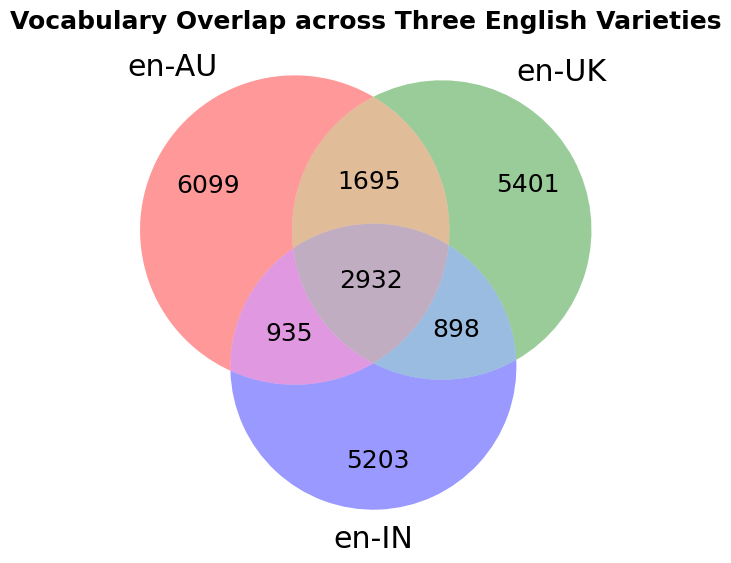

In [17]:
plt.figure(figsize=(8, 6))
venn3([vocabulary_au, vocabulary_uk, vocabulary_in], set_labels=('en-AU', 'en-UK', 'en-IN'))
plt.title('Vocabulary Overlap across Three English Varieties', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/venn_vocabulary.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 17 - POS Distribution Across Varieties

This section compares **part-of-speech (POS)** distributions across varieties. POS analysis adds a broader linguistic perspective by showing whether varieties differ not only in vocabulary, but also in their structural or stylistic patterns of language use.

Computing POS distributions



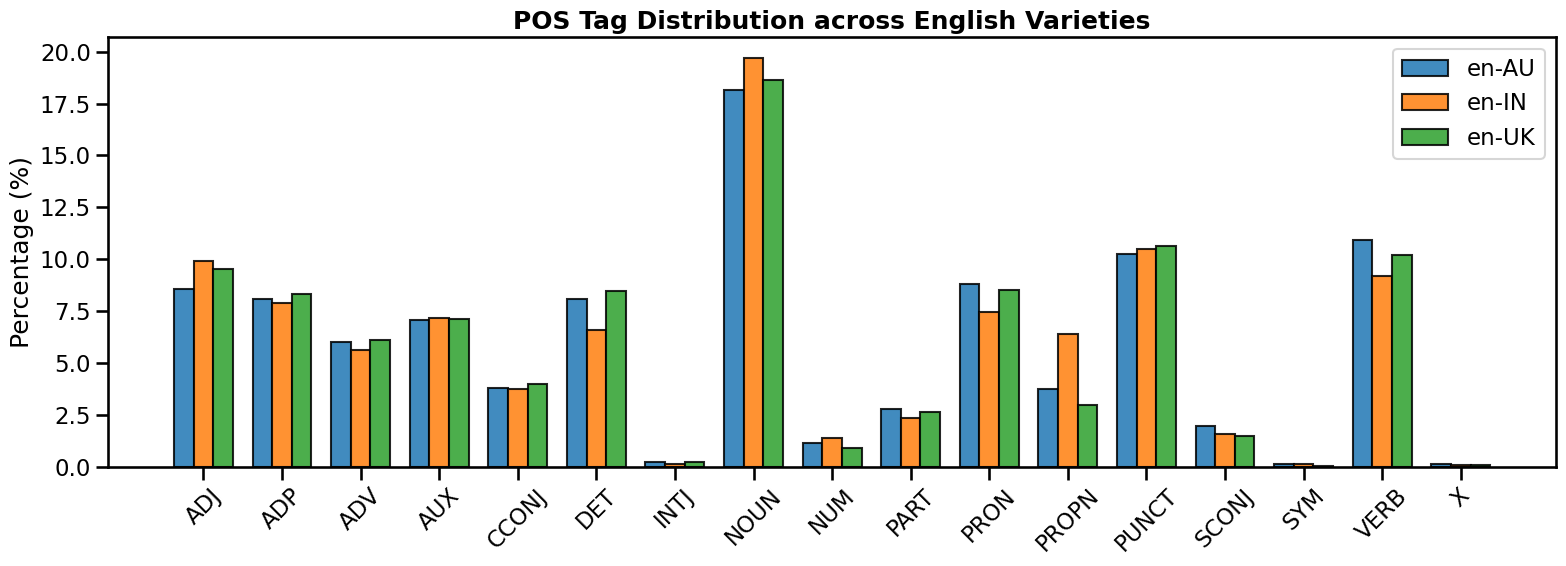

In [18]:
def get_pos_distribution(data_frames, variety, sample_size=300):
    texts = data_frames[data_frames['variety'] == variety]['text'].dropna().sample(
            min(sample_size, len(data_frames[data_frames['variety'] == variety])), random_state=42).tolist()
    pos_counts = Counter()
    for text in texts:
        doc = nlp(text[:500])
        for token in doc:
            if not token.is_space:
                pos_counts[token.pos_] += 1
    total = sum(pos_counts.values())
    return {k: v/total*100 for k, v in pos_counts.items()}

print("Computing POS distributions\n")
pos_distribution = {v: get_pos_distribution(train, v) for v in varieties}

# Plot
all_pos_tags = sorted(set(tag for d in pos_distribution.values() for tag in d.keys()))
x = np.arange(len(all_pos_tags))
width = 0.25

figure, axes = plt.subplots(figsize=(16, 6))
for i, variety in enumerate(varieties):
    values = [pos_distribution[variety].get(tag, 0) for tag in all_pos_tags]
    axes.bar(x + i*width, values, width, label=variety, alpha=0.85, edgecolor='black')

axes.set_xticks(x + width)
axes.set_xticklabels(all_pos_tags, rotation=45)
axes.set_ylabel('Percentage (%)')
axes.set_title('POS Tag Distribution across English Varieties', fontweight='bold')
axes.legend()
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/pos_distribution.png', dpi=150, bbox_inches='tight')
plt.show()